# Series de tiempo






Para esta clase, vamos a trabajar con datos del Banco Mundial, utilizando la API `Data360` del Banco Mundial.


Vamos a explorar brevemente la API desde su sitio web: [API World Bank](https://data360.worldbank.org/en/api#)

Este notebook ya contiene un bloque de código que descarga datos poblacionales para la Argentina de la base WB_WDI y del indicador WB_WDI_SP_POP_TOTL

---
## 1. Configuración e Imports
Instalamos e importamos las librerías necesarias y definimos la URL base de la API.

In [1]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# import altair as alt
# alt.renderers.enable('colab')
# alt.data_transformers.disable_max_rows()
# from IPython.display import display

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', 80)

BASE_URL = "https://data360api.worldbank.org"

---
## 2. Función para hacer peticiones a la API
A continuación, definimos una función reutilizable que maneja Requests HTTP y devuelven la respuesta en formato JSON.

In [2]:
 # Realiza una petición GET a la API y retorna el JSON de respuesta
def get_api(endpoint, params=None):
    url = f"{BASE_URL}{endpoint}"
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()


---
## 3. Recuperación de datos
El endpoint `/data360/data` es el núcleo de la API. Retorna observaciones con la siguiente estructura:
- **REF_AREA**: código de país o región
- **TIME_PERIOD**: año o período
- **INDICATOR**: ID del indicador
- **OBS_VALUE**: valor observado
- **SEX, AGE, URBANISATION**: dimensiones de desagregación
- **FREQ**: frecuencia (A=anual, Q=trimestral, M=mensual)

Preparamos el diccionario `params_data` de manera de traernos:
* datos de la base "WB_WDI",
* del indicador "WB_WDI_SP_POP_TOTL",
* del país "ARG"

In [19]:
# traemos datos del indicador de población total para todos los países
params_data = {
    "DATABASE_ID": "WB_WDI",
    "INDICATOR": "WB_WDI_SP_POP_TOTL",
    "REF_AREA": "ARG",
    "skip": 0
}

resp_data = get_api("/data360/data", params=params_data)

total_records = resp_data.get('count', 0)
data  = resp_data.get('value', [])

print(f"Total de registros disponibles: {total_records}")
print(f"Total de registros descargados: {len(data)}")
print(data)

Total de registros disponibles: 17195
Total de registros descargados: 1000
[{'OBS_VALUE': '24476008', 'TIME_FORMAT': 'P1Y', 'UNIT_MULT': 0, 'COMMENT_OBS': None, 'OBS_STATUS': 'A', 'OBS_CONF': 'PU', 'AGG_METHOD': '_Z', 'DECIMALS': '2', 'COMMENT_TS': None, 'DATA_SOURCE': None, 'LATEST_DATA': False, 'DATABASE_ID': 'WB_WDI', 'INDICATOR': 'WB_WDI_SP_POP_TOTL', 'REF_AREA': 'UZB', 'SEX': '_T', 'AGE': '_T', 'URBANISATION': '_T', 'COMP_BREAKDOWN_1': '_Z', 'COMP_BREAKDOWN_2': '_Z', 'COMP_BREAKDOWN_3': '_Z', 'TIME_PERIOD': '1999', 'FREQ': 'A', 'UNIT_MEASURE': 'PS', 'UNIT_TYPE': None}, {'OBS_VALUE': '182048', 'TIME_FORMAT': 'P1Y', 'UNIT_MULT': 0, 'COMMENT_OBS': None, 'OBS_STATUS': 'A', 'OBS_CONF': 'PU', 'AGG_METHOD': '_Z', 'DECIMALS': '2', 'COMMENT_TS': None, 'DATA_SOURCE': None, 'LATEST_DATA': False, 'DATABASE_ID': 'WB_WDI', 'INDICATOR': 'WB_WDI_SP_POP_TOTL', 'REF_AREA': 'VUT', 'SEX': '_T', 'AGE': '_T', 'URBANISATION': '_T', 'COMP_BREAKDOWN_1': '_Z', 'COMP_BREAKDOWN_2': '_Z', 'COMP_BREAKDOWN_3': 

Convertimos los datos en un DataFrame y exploramos su estructura.

In [4]:
# try:
#   dict_test = []
#   pd_test = pd.DataFrame(dict_test)
#   pd_test.head()
# except Exception as e:
#   print(e)


In [20]:
# Convertimos el JSON (lista de diccionarios) a Dataframe
df = pd.DataFrame(data)
df.head()

,OBS_VALUE,TIME_FORMAT,UNIT_MULT,COMMENT_OBS,OBS_STATUS,OBS_CONF,AGG_METHOD,DECIMALS,COMMENT_TS,DATA_SOURCE,...,SEX,AGE,URBANISATION,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,FREQ,UNIT_MEASURE,UNIT_TYPE
0,24476008,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
1,182048,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
2,24066593,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
3,76287452,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
4,108599,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None


## EDA para ver la estructura y seleccionar datos de interés

In [21]:
# Listamos las columnas
df.columns

Index(['OBS_VALUE', 'TIME_FORMAT', 'UNIT_MULT', 'COMMENT_OBS', 'OBS_STATUS',
       'OBS_CONF', 'AGG_METHOD', 'DECIMALS', 'COMMENT_TS', 'DATA_SOURCE',
       'LATEST_DATA', 'DATABASE_ID', 'INDICATOR', 'REF_AREA', 'SEX', 'AGE',
       'URBANISATION', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2',
       'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'FREQ', 'UNIT_MEASURE', 'UNIT_TYPE'],
      dtype='object')

In [22]:
# Seleccionamos las columnas de interes
df = df[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']]
df.head()

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,UZB,1999,24476008
1,VUT,1999,182048
2,VEN,1999,24066593
3,VNM,1999,76287452
4,VIR,1999,108599


In [23]:
# Exploremos la estructura del dataframe resultante
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   REF_AREA     1000 non-null   object
 1   TIME_PERIOD  1000 non-null   object
 2   OBS_VALUE    1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


In [9]:
# Convertimos TIME_PERIOD y OBS_VALUE a numeric
df['TIME_PERIOD'] = pd.to_numeric(df['TIME_PERIOD'], errors='coerce')
df['OBS_VALUE']   = pd.to_numeric(df['OBS_VALUE'], errors='coerce')


In [10]:
df.describe()

,TIME_PERIOD,OBS_VALUE
count,65.00000,6.500000e+01
mean,1992.00000,3.346170e+07
std,18.90767,8.028166e+06
min,1960.00000,2.038604e+07
25%,1976.00000,2.628228e+07
50%,1992.00000,3.369353e+07
75%,2008.00000,4.042415e+07
max,2024.00000,4.569616e+07


In [11]:
df.describe(include='object')

,REF_AREA
count,65
unique,1
top,ARG
freq,65


In [12]:
# plt.figure(figsize=(12, 6)) # tamaño del lienzo, horizontal 12 x 6
# plt.subplot(1, 2, 2) # 1 fila, 2 columnas, 1 cuadrante
# sns.histplot(data=df, x='OBS_VALUE', bins="auto")

# plt.subplot(1, 2, 1) # 1 fila, 2 columnas, 2 cuadrante
# sns.boxplot(data=df, y='OBS_VALUE')
# plt.show()

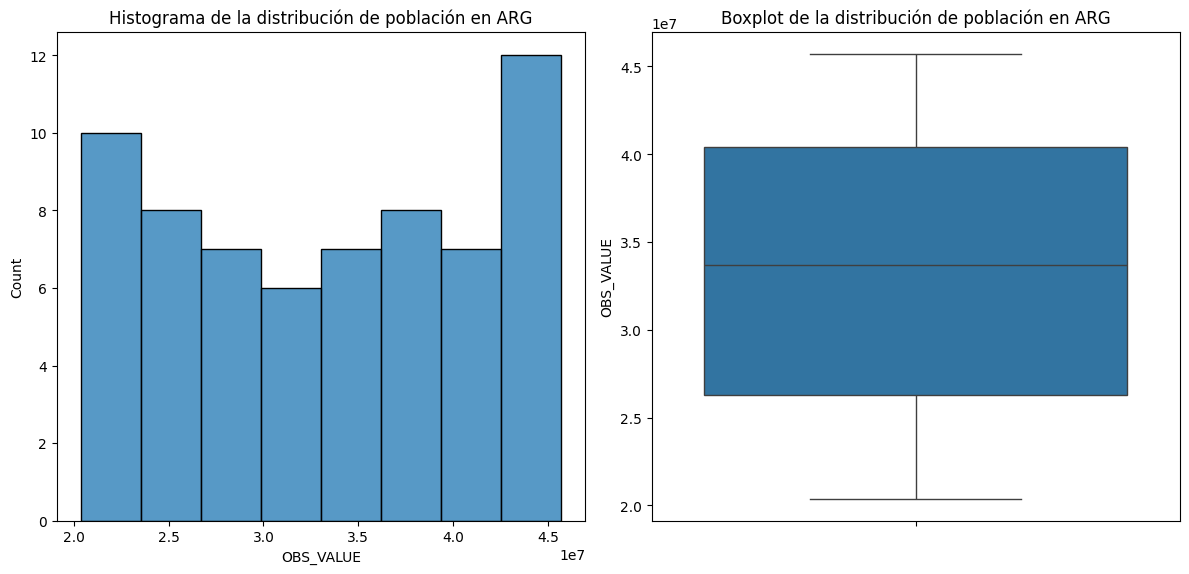

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='OBS_VALUE', bins="auto")
plt.title("Histograma de la distribución de población en ARG")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='OBS_VALUE')
plt.title("Boxplot de la distribución de población en ARG")

plt.tight_layout()
plt.show()

## Exportamos a csv

In [14]:
df.to_csv('poblacion_argentina.csv', index=False)

## Graficamos evolución de Población

In [15]:
df_plot = df[df['TIME_PERIOD'] > 2000]
df_plot.head()

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,ARG,2009,40854831
1,ARG,2006,39622115
2,ARG,2003,38424282
3,ARG,2005,39216789
4,ARG,2001,37624825


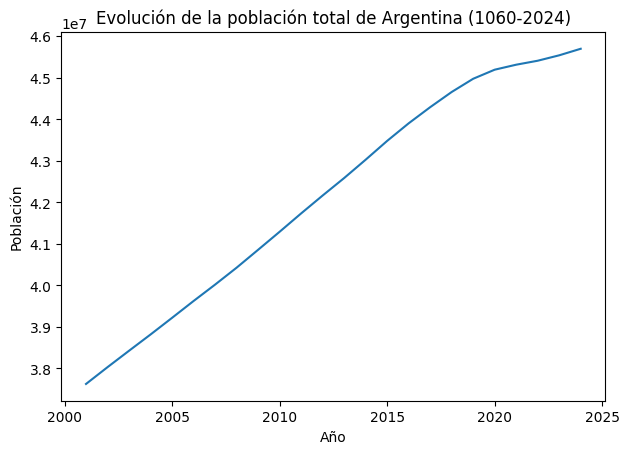

In [16]:
# libreria seaborn, metodo "lineplot" para linea de tiempo o serie de tiempo
sns.lineplot(
    data=df_plot, # dato o dataframe
    x='TIME_PERIOD', # variable en X
    y='OBS_VALUE' # variable en Y
)

plt.title("Evolución de la población total de Argentina (1060-2024)")
plt.xlabel("Año") # Etiqueta en el eje X
plt.ylabel("Población") # Etiqueta en el eje X

plt.tight_layout() # ajuste automatico
plt.show()

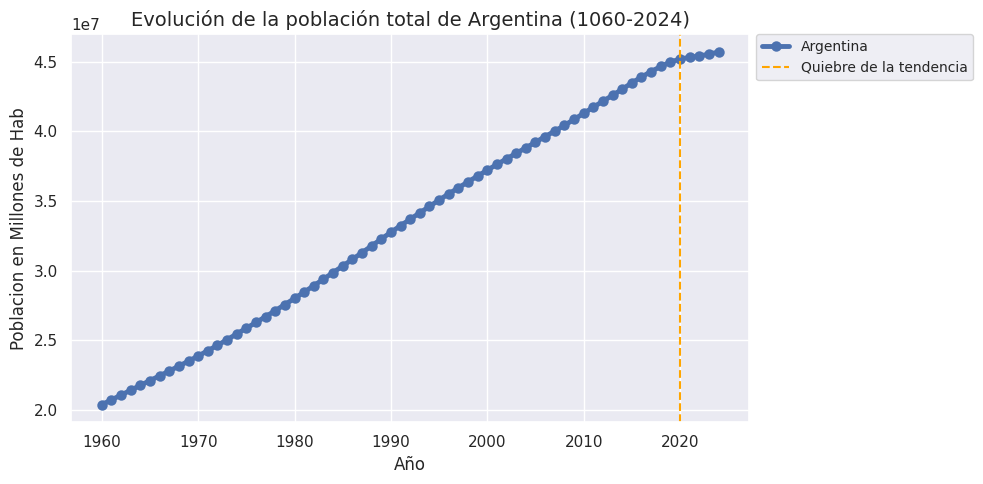

In [17]:
# ── 1. Estilo global ────────────────────────────────────────
sns.set_theme(
    style='darkgrid',
    context='notebook',
    palette='deep'
)

# ── 2. Figura y lineplot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    x='TIME_PERIOD', y='OBS_VALUE', data=df,
    linewidth=3.5, linestyle='-',
    marker='o', markersize=6,
    markeredgecolor='auto', markeredgewidth=1.5,
    label='Argentina'
)

# ── vline ──
plt.axvline(x=2020, color='orange', linestyle='--', label='Quiebre de la tendencia')

# ── 3. Títulos y etiquetas ──────────────────────────────────
plt.title('Evolución de la población total de Argentina (1060-2024)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Poblacion en Millones de Hab')

# ── 4. Leyenda ──────────────────────────────────────────────
plt.legend(
    fontsize=10, frameon=True,
    bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0
)

plt.tight_layout()
plt.show()

# Playground

Personalizamos el gráfico!

Descargar el siguiente código html y abrirlo localmente desde un Browser

[Playground](https://drive.google.com/file/d/1-Zq05uo3VeFwQn9Lo0PWDpQRoReyB1Ch/view?usp=drive_link)

Explorar los diferentes settings, copiar el código generado en un bloque de este Notebook y ejecutarlo. Analizar cada uno de los bloques y sus posibles settings.

In [18]:
# Pega el código del Playground aquí

# Bonus track
Ya probaste [Flourish](https://flourish.studio/)?

Podes importar el csv y generar una serie de tiempo que luego podes importar en un proyecto o sitio web. Tambien podes hacer un chart race!
Pensemos como representar la evolucion de la poblacion mundial a partir de la API del Banco Mundial!